In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Sorting is important for time series data
df = pd.read_csv("../data/raw/ed_arrivals.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")
df.head()

,timestamp,arrivals,day_of_week,is_weekend,is_holiday,hour
0,2026-01-01 00:00:00,3,Thursday,0,1,0
1,2026-01-01 01:00:00,2,Thursday,0,1,1
2,2026-01-01 02:00:00,3,Thursday,0,1,2
3,2026-01-01 03:00:00,4,Thursday,0,1,3
4,2026-01-01 04:00:00,2,Thursday,0,1,4


In [3]:
#Create lag features for the arrivals column. Lag features are useful in time series forecasting as they provide information about past values of the target variable, which can help the model learn patterns and trends over time.
df["lag_1"] = df["arrivals"].shift(1)
df["lag_2"] = df["arrivals"].shift(2)
df["lag_3"] = df["arrivals"].shift(3)
df["lag_6"] = df["arrivals"].shift(6)
df["lag_24"] = df["arrivals"].shift(24)

In [4]:
df["rolling_mean_6"] = (
    df["arrivals"]
    .shift(1)
    .rolling(window=6)
    .mean()
)

df["rolling_mean_24"] = (
    df["arrivals"]
    .shift(1) # if we don't shift, the rolling mean will include the current value, which is not available at prediction time(data leakage)
    .rolling(window=24)
    .mean()
)

In [5]:
df.head(30)

,timestamp,arrivals,day_of_week,is_weekend,is_holiday,hour,lag_1,lag_2,lag_3,lag_6,lag_24,rolling_mean_6,rolling_mean_24
0,2026-01-01 00:00:00,3,Thursday,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-01-01 01:00:00,2,Thursday,0,1,1,3.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-01-01 02:00:00,3,Thursday,0,1,2,2.0,3.0,NaN,NaN,NaN,NaN,NaN
3,2026-01-01 03:00:00,4,Thursday,0,1,3,3.0,2.0,3.0,NaN,NaN,NaN,NaN
4,2026-01-01 04:00:00,2,Thursday,0,1,4,4.0,3.0,2.0,NaN,NaN,NaN,NaN
5,2026-01-01 05:00:00,2,Thursday,0,1,5,2.0,4.0,3.0,NaN,NaN,NaN,NaN
6,2026-01-01 06:00:00,4,Thursday,0,1,6,2.0,2.0,4.0,3.0,NaN,2.666667,NaN
7,2026-01-01 07:00:00,7,Thursday,0,1,7,4.0,2.0,2.0,2.0,NaN,2.833333,NaN
8,2026-01-01 08:00:00,5,Thursday,0,1,8,7.0,4.0,2.0,3.0,NaN,3.666667,NaN
9,2026-01-01 09:00:00,7,Thursday,0,1,9,5.0,7.0,4.0,4.0,NaN,4.000000,NaN


In [6]:
df_model = df.dropna().copy()
df_model.shape

(8736, 13)

In [7]:
features = [
    "hour",
    "is_weekend",
    "is_holiday",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_24",
    "rolling_mean_6",
    "rolling_mean_24",
]

target = "arrivals"

In [8]:
split_index = int(len(df_model) * 0.8)

train = df_model.iloc[:split_index].copy()
test = df_model.iloc[split_index:].copy()

print("Training rows:", len(train))
print("Testing rows:", len(test))

Training rows: 6988
Testing rows: 1748


In [9]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (6988, 10)
y_train: (6988,)
X_test: (1748, 10)
y_test: (1748,)


In [10]:
# Random forest for training the model

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train,
    y_train,
)

print("Model trained successfully!")

Model trained successfully!


In [11]:
predictions = model.predict(X_test)

predictions[:10]

array([3.55, 3.5 , 3.13, 7.43, 7.74, 6.78, 6.42, 7.43, 7.31, 7.18])

In [12]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae = mean_absolute_error(
    y_test,
    predictions,
)

rmse = root_mean_squared_error(
    y_test,
    predictions,
)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 1.31
RMSE: 1.66


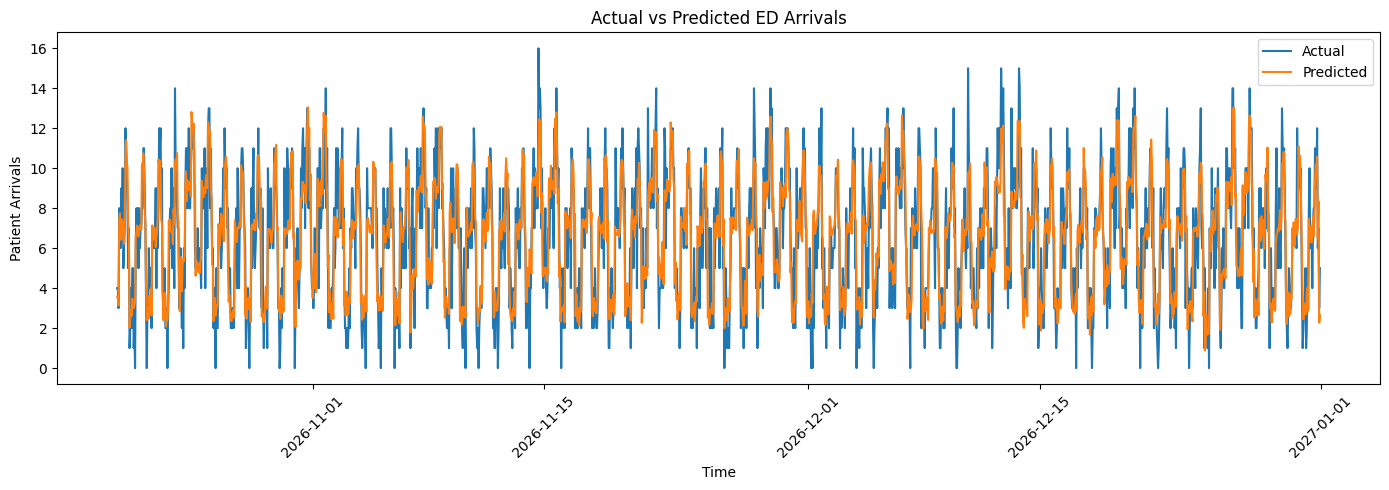

In [13]:
results = test[
    ["timestamp", "arrivals"]
].copy()

results["predicted"] = predictions
results.head()
plt.figure(figsize=(14, 5))

plt.plot(
    results["timestamp"],
    results["arrivals"],
    label="Actual",
)

plt.plot(
    results["timestamp"],
    results["predicted"],
    label="Predicted",
)

plt.title("Actual vs Predicted ED Arrivals")
plt.xlabel("Time")
plt.ylabel("Patient Arrivals")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()